Khai báo thư viện 

In [1]:
import cv2
import matplotlib.pyplot as quan


Kiểm tra opencv đọc ảnh và đặt ảnh cho đúng hiển thị ban đầu

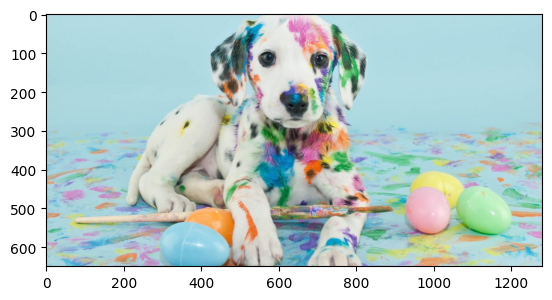

In [3]:
img = cv2.imread('dog.png')
img = img[:,:,::-1]
quan.imshow(img)


1. Thực hành xử lý ảnh trong miền tần số: 


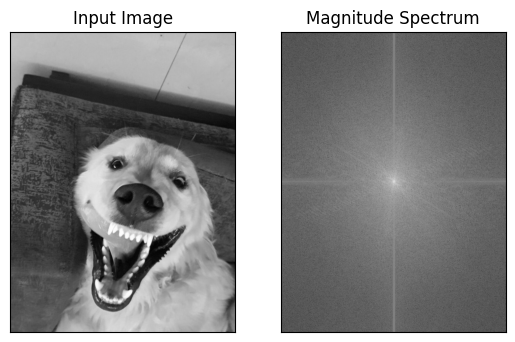

In [8]:
import numpy as np                     # Thư viện tính toán ma trận
import cv2                             # Thư viện xử lý ảnh OpenCV
import matplotlib.pyplot as quan       # Import matplotlib và đặt bí danh theo tên sinh viên

img = cv2.imread('puppy_ex1.jpg',0)        # Đọc ảnh hinh1.jpg ở chế độ grayscale
img_float32 = np.float32(img)          # Chuyển dữ liệu ảnh sang kiểu float32 để xử lý FFT

dft = cv2.dft(img_float32, flags=cv2.DFT_COMPLEX_OUTPUT)   # Biến đổi Fourier rời rạc (DFT)
dft_shift = np.fft.fftshift(dft)       # Dịch chuyển tần số thấp vào trung tâm phổ

magnitude_spectrum = 20*np.log(cv2.magnitude(dft_shift[:,:,0], dft_shift[:,:,1]))  
# Tính phổ biên độ và đưa về thang log để tăng độ tương phản

quan.subplot(121)                      # Chia cửa sổ hiển thị thành 1 hàng 2 cột (ảnh gốc)
quan.imshow(img, cmap='gray')          # Hiển thị ảnh gốc
quan.title('Input Image')              # Tiêu đề ảnh
quan.xticks([])                        # Ẩn trục x
quan.yticks([])                        # Ẩn trục y

quan.subplot(122)                      # Vị trí hiển thị ảnh thứ 2
quan.imshow(magnitude_spectrum, cmap='gray')   # Hiển thị phổ tần số
quan.title('Magnitude Spectrum')       # Tiêu đề phổ tần số
quan.xticks([])                        # Ẩn trục x
quan.yticks([])                        # Ẩn trục y

quan.show()                            # Hiển thị toàn bộ kết quả


2. Sử dụng đoạn code sau cho DFT, trình bày ý nghĩa của từng dòng lệnh. 

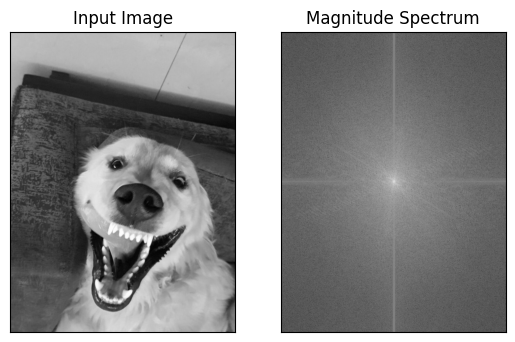

In [ ]:
quan.subplot(121), quan.imshow(img, cmap='gray')        # Hiển thị ảnh gốc ở vị trí 1
quan.title('Input Image'), quan.xticks([]), quan.yticks([])   # Đặt tiêu đề và ẩn trục
quan.subplot(122), quan.imshow(magnitude_spectrum, cmap='gray')  # Hiển thị phổ tần số
quan.title('Magnitude Spectrum'), quan.xticks([]), quan.yticks([]) # Đặt tiêu đề và ẩn trục
quan.show()   # Hiển thị cửa sổ kết quả

3. Sử dụng Fast Fourier Transform (FFT) Magnitude algorithm để phát hiện ảnh mờ

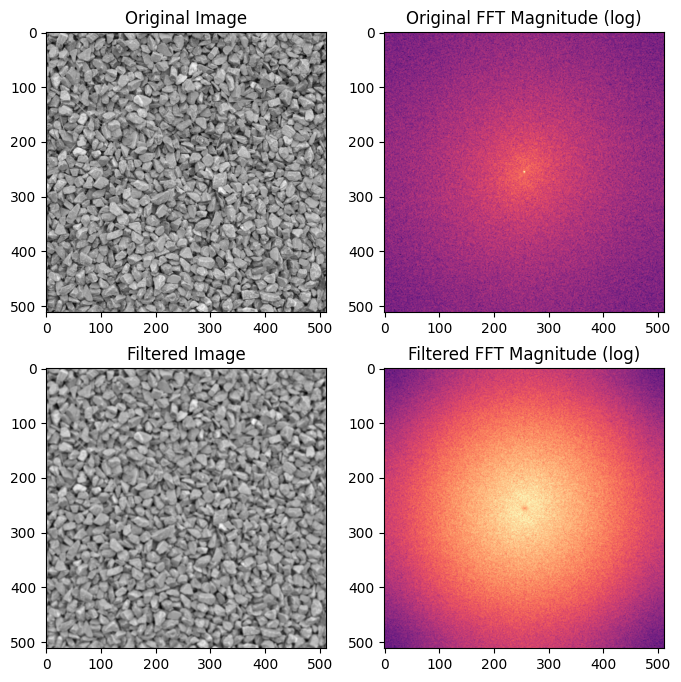

In [10]:

import matplotlib.pyplot as quan              # Thư viện hiển thị ảnh, đặt bí danh theo tên sinh viên
import numpy as np                            # Thư viện tính toán ma trận
from skimage.data import gravel               # Lấy ảnh mẫu gravel từ skimage
from skimage.filters import difference_of_gaussians, window   # Bộ lọc Gaussian và hàm window
from scipy.fft import fftn, fftshift          # Hàm FFT và dịch chuyển phổ tần số

image = gravel()                              # Lấy ảnh mẫu gravel
wimage = image * window('hann', image.shape)  # Áp dụng cửa sổ Hann để giảm nhiễu khi FFT

filtered_image = difference_of_gaussians(image, 1, 12)  # Lọc ảnh bằng Difference of Gaussians
filtered_wimage = filtered_image * window('hann', image.shape)  # Áp dụng window cho ảnh đã lọc

im_f_mag = fftshift(np.abs(fftn(wimage)))     # Tính FFT của ảnh gốc và dịch tần số thấp về giữa
fim_f_mag = fftshift(np.abs(fftn(filtered_wimage)))  # Tính FFT của ảnh đã lọc

fig, ax = quan.subplots(nrows=2, ncols=2, figsize=(8, 8))  # Tạo khung hiển thị 2x2

ax[0, 0].imshow(image, cmap='gray')           # Hiển thị ảnh gốc
ax[0, 0].set_title('Original Image')          # Tiêu đề ảnh gốc

ax[0, 1].imshow(np.log(im_f_mag), cmap='magma')   # Hiển thị phổ FFT của ảnh gốc
ax[0, 1].set_title('Original FFT Magnitude (log)')  # Tiêu đề phổ FFT

ax[1, 0].imshow(filtered_image, cmap='gray')  # Hiển thị ảnh sau khi lọc DoG
ax[1, 0].set_title('Filtered Image')          # Tiêu đề ảnh đã lọc

ax[1, 1].imshow(np.log(fim_f_mag), cmap='magma')  # Hiển thị phổ FFT của ảnh đã lọc
ax[1, 1].set_title('Filtered FFT Magnitude (log)')  # Tiêu đề phổ FFT sau lọc

quan.show()                                   # Hiển thị toàn bộ hình